#  Telecom Customer Churn Prediction using Machine Learning

This project aims to predict customer churn in a telecommunications company using machine learning techniques. The analysis includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, hyperparameter tuning, and model interpretation.

In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Download dataset from Kaggle
path = kagglehub.dataset_download("abdallahwagih/telco-customer-churn")

print(f"Dataset path: {path}")

# Display files in the dataset folder
files = os.listdir(path)
print("Files:", files)

# Load dataset
df = pd.read_excel(os.path.join(path, "Telco_customer_churn.xlsx"))

# Display the first five rows
df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset path: /kaggle/input/telco-customer-churn
Files: ['Telco_customer_churn.xlsx']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [19]:
# Dataset dimensions
df.shape

# Column names
df.columns

# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [20]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()

print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

Total missing values: 5174




The dataset contains missing values only in the **Churn Reason** column (5,174 missing values). This is expected because the reason for churn is available only for customers who have already left the company. Therefore, this feature will not be used for model training, as it could introduce data leakage.

In [21]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count}")
print(f"Percentage of duplicate records: {duplicate_count / len(df) * 100:.2f}%")

Number of duplicate records: 0
Percentage of duplicate records: 0.00%


##DATA CLEANING

In [22]:
# Convert 'Total Charges' to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [23]:
# Check missing values after converting Total Charges
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [24]:
# Remove rows with missing values in 'Total Charges'
df = df.dropna(subset=['Total Charges']).reset_index(drop=True)

# Check the new dataset dimensions
df.shape

# Check missing values again
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


The missing values in **Total Charges** were successfully removed by deleting the corresponding 11 records. The only remaining missing values are in **Churn Reason**, which is expected since this information is available only for customers who have churned. This feature will be excluded from model training to avoid data leakage.

In [25]:
# Check the number of unique values in each column
df.nunique().sort_values()

,0
Count,1
Country,1
State,1
Phone Service,2
Dependents,2
Partner,2
Senior Citizen,2
Gender,2
Churn Value,2
Paperless Billing,2


In [26]:
# Remove unnecessary columns

columns_to_drop = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'Churn Label',
    'Churn Score',
    'Churn Reason'
]

df = df.drop(columns=columns_to_drop)

# Display the new dataset dimensions
df.shape

(7032, 26)

After the data cleaning process, the dataset contains **7,032 observations** and **26 features**. Missing values in `Total Charges` were removed, and columns with no predictive value or potential data leakage were excluded. The dataset is now ready for exploratory data analysis (EDA).

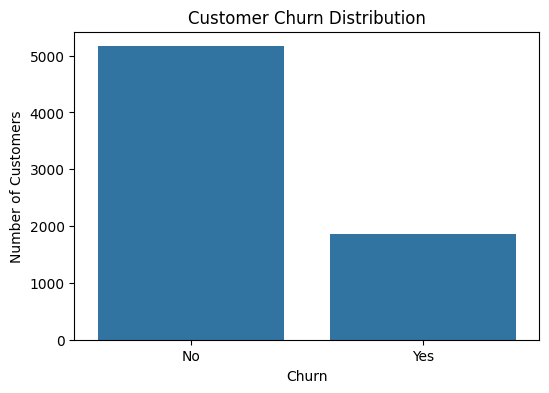

In [27]:
# Distribution of the target variable (Churn)

plt.figure(figsize=(6,4))
sns.countplot(x='Churn Value', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ['No', 'Yes'])

plt.show()



The target variable is imbalanced, with considerably more customers who stayed than customers who churned. Therefore, model performance should be evaluated using metrics such as Precision, Recall, F1-score, and ROC-AUC, rather than Accuracy alone.

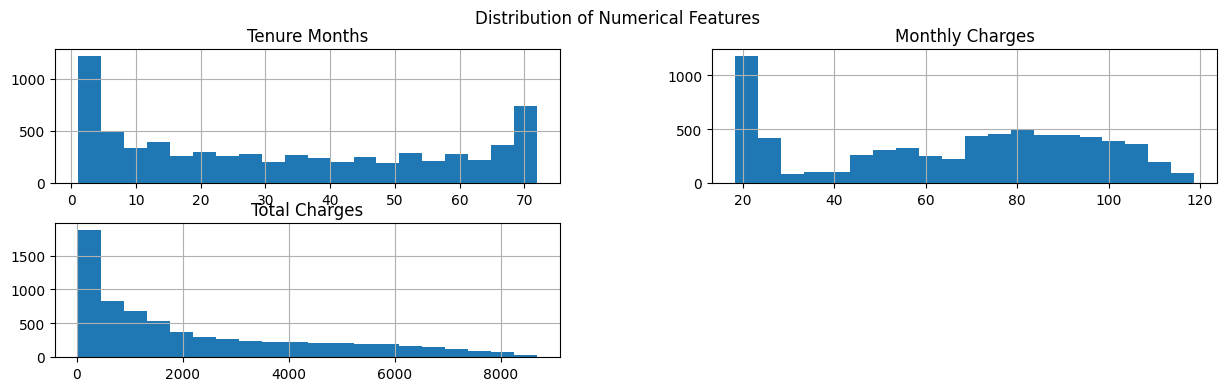

In [28]:
# Histograms of numerical features

numerical_features = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges'
]

df[numerical_features].hist(figsize=(15,4), bins=20)

plt.suptitle("Distribution of Numerical Features")
plt.show()

The numerical features show different distributions. **Tenure Months** has a higher concentration of customers with very short and very long subscriptions. **Monthly Charges** are distributed over a wide range, while **Total Charges** is right-skewed, with most customers having relatively low total charges and fewer customers with very high values.

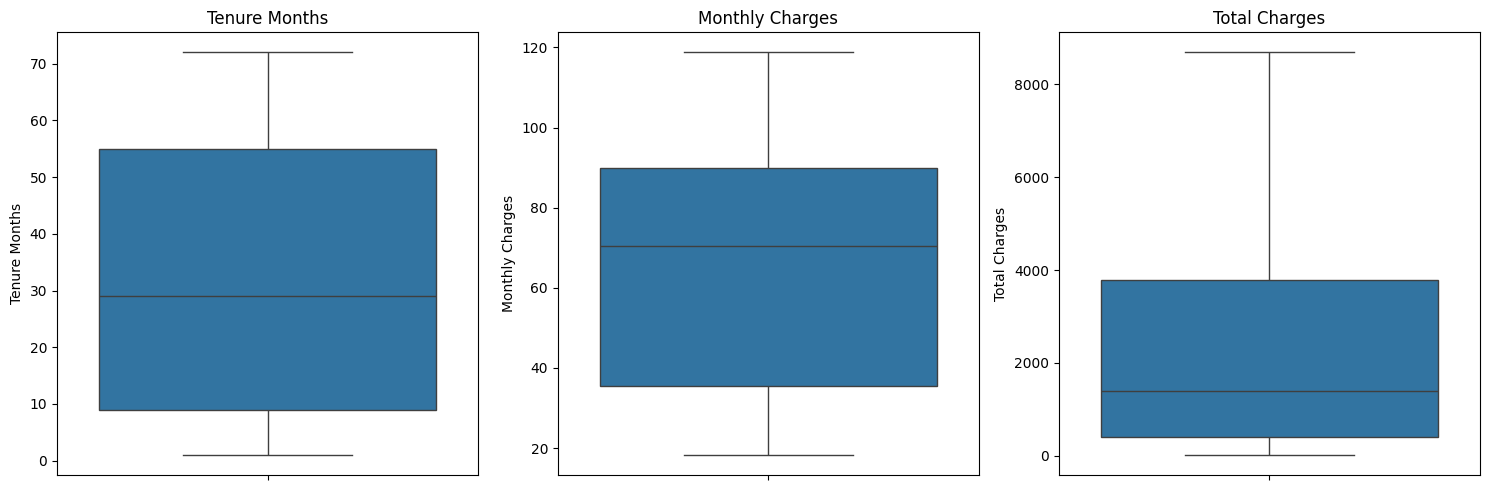

In [29]:
# Boxplots for numerical features

plt.figure(figsize=(15,5))

for i, col in enumerate(numerical_features):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

No significant outliers were observed in the numerical features, so no outlier removal was performed.

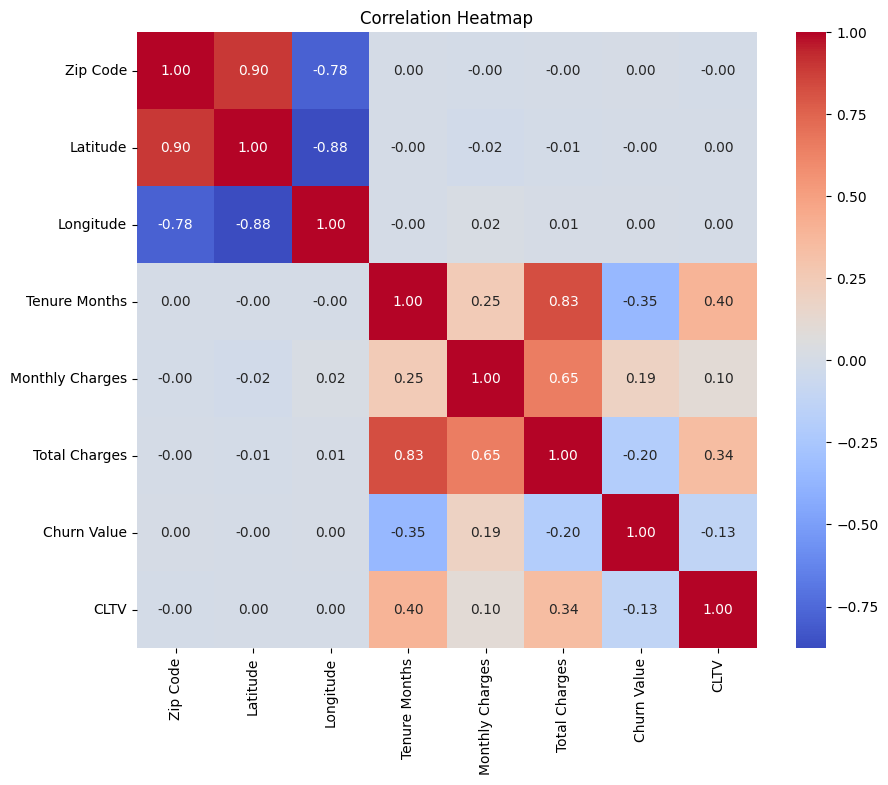

In [30]:
# Correlation heatmap

plt.figure(figsize=(10,8))

numerical_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

The strongest positive correlation is between **Tenure Months** and **Total Charges** (0.83), indicating that customers who stay longer tend to accumulate higher total charges. In addition, **Churn Value** has a moderate negative correlation with **Tenure Months** (-0.35), suggesting that customers with longer subscriptions are less likely to churn.

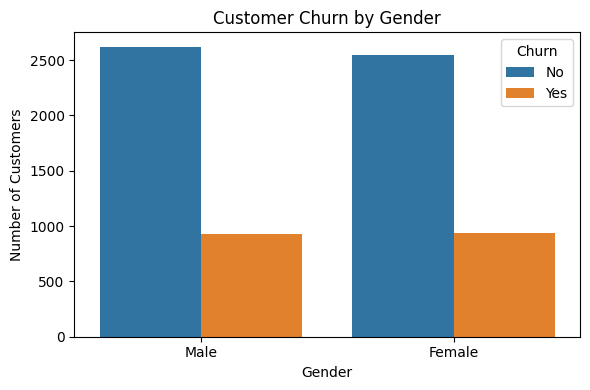

In [32]:
# Churn by Gender

plt.figure(figsize=(6, 4))

sns.countplot(
    x="Gender",
    hue="Churn Value",
    data=df
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(
    title="Churn",
    labels=["No", "Yes"]
)

plt.tight_layout()
plt.show()

The churn distribution is very similar for both male and female customers. This suggests that gender is not a strong factor in predicting customer churn.

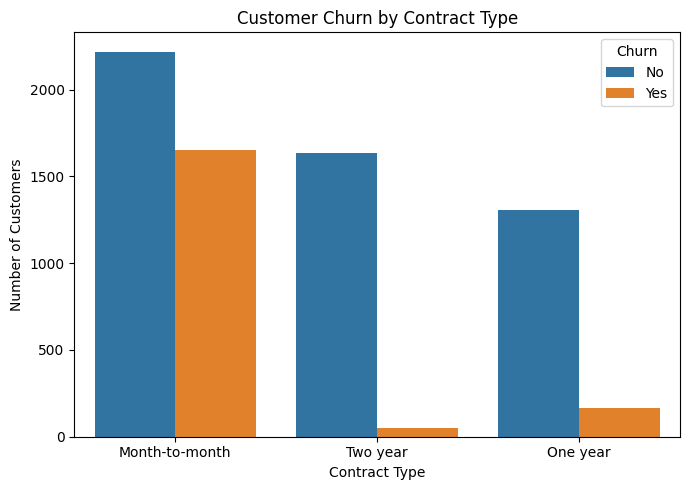

In [33]:
# Churn by Contract Type

plt.figure(figsize=(7,5))

sns.countplot(
    x="Contract",
    hue="Churn Value",
    data=df
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

#Customers with **month-to-month** contracts have the highest churn rate, while customers with **one-year** and **two-year** contracts are much less likely to leave the company.

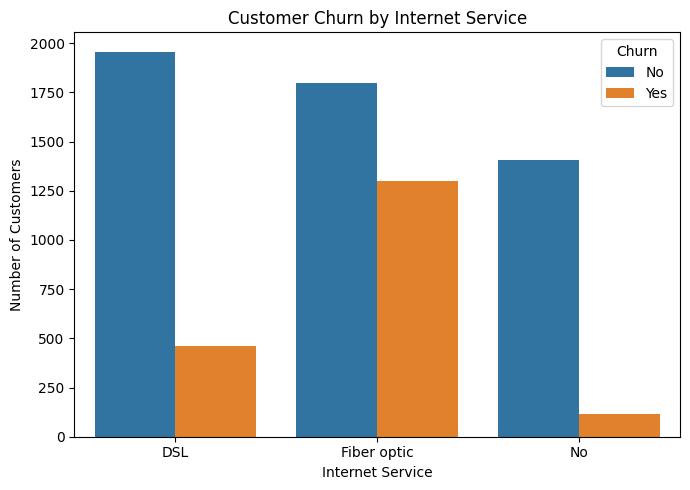

In [34]:
# Churn by Internet Service

plt.figure(figsize=(7,5))

sns.countplot(
    x="Internet Service",
    hue="Churn Value",
    data=df
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

Customers with **Fiber optic** internet service have the highest churn rate, while customers with **DSL** or **no internet service** are less likely to leave the company.

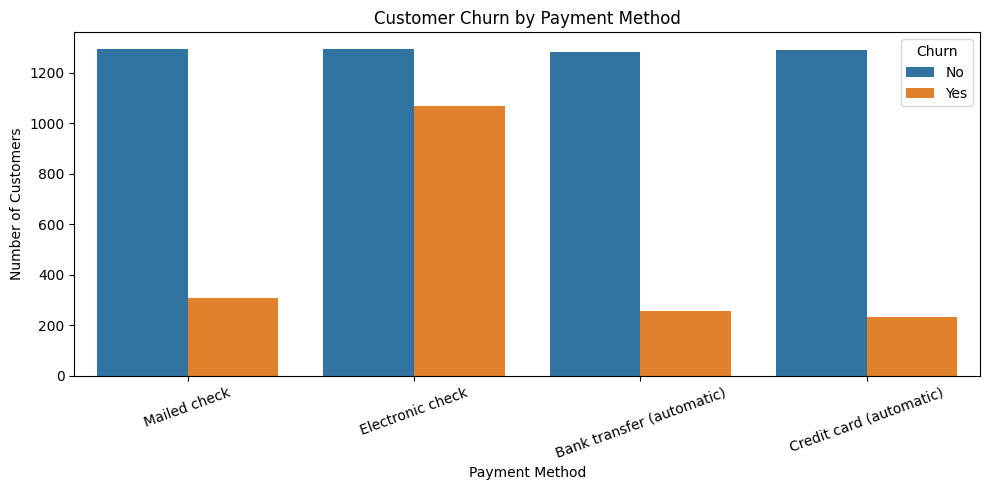

In [35]:
# Churn by Payment Method

plt.figure(figsize=(10,5))

sns.countplot(
    x="Payment Method",
    hue="Churn Value",
    data=df
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)
plt.legend(title="Churn", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

Customers who use **Electronic check** have the highest churn rate, while customers using **automatic payment methods** (bank transfer or credit card) are less likely to leave the company.

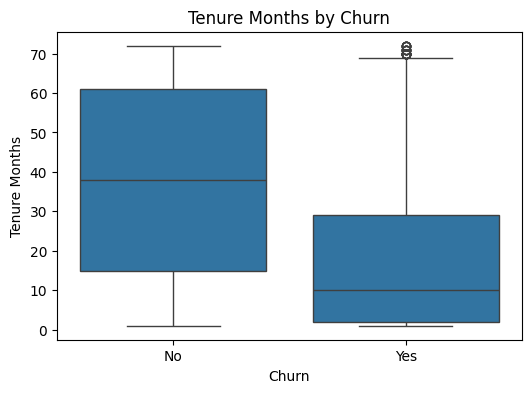

In [36]:
# Tenure Months by Churn

plt.figure(figsize=(6,4))

sns.boxplot(x="Churn Value", y="Tenure Months", data=df)

plt.title("Tenure Months by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")

plt.xticks([0,1], ["No","Yes"])

plt.show()


Customers who churn have a much shorter subscription period than customers who stay with the company. This suggests that customers with lower tenure are more likely to churn.

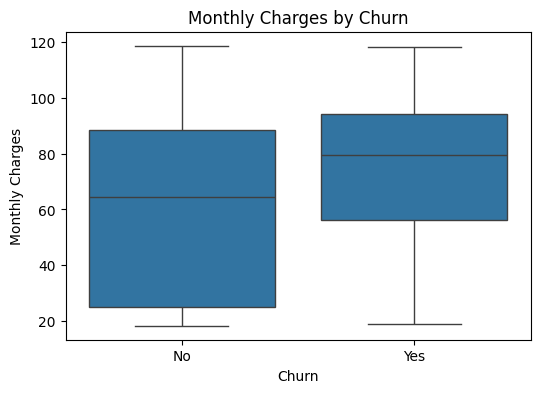

In [37]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn Value", y="Monthly Charges", data=df)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.xticks([0,1], ["No","Yes"])

plt.show()



Customers who churn tend to have higher monthly charges than customers who remain with the company.

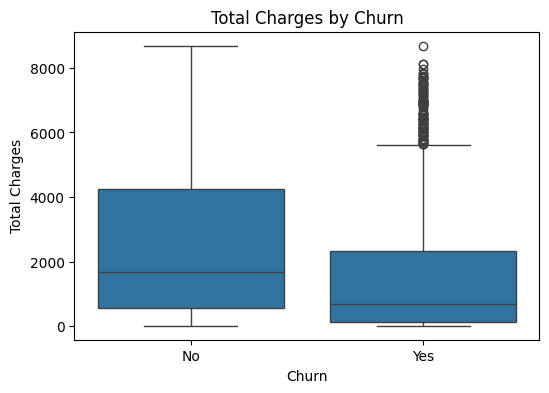

In [38]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn Value", y="Total Charges", data=df)

plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.xticks([0,1], ["No","Yes"])

plt.show()



Customers who churn generally have lower total charges than customers who stay with the company. This is consistent with the fact that churning customers usually have a shorter subscription period.

## EDA Summary

### Key Findings

- The dataset is imbalanced, with more customers staying than leaving.
- Customers with month-to-month contracts have the highest churn rate.
- Customers using Fiber optic internet service are more likely to churn.
- Customers paying by Electronic check show higher churn rates.
- Customers who churn generally have shorter subscription periods.
- Customers who churn tend to have higher monthly charges but lower total charges.
- Gender does not appear to have a significant impact on customer churn.

##Data Preprocessing

In [44]:
# Define features and target

X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [45]:
# Separate numerical and categorical features

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Numerical features:
['Tenure Months', 'Monthly Charges', 'Total Charges']


The dataset contains **16 categorical features** and **3 numerical features**. Categorical variables will be encoded using One-Hot Encoding, while numerical variables will be scaled when required by the machine learning models.

In [46]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5625, 19)
Testing set: (1407, 19)


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Data preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)



In [48]:
# Logistic Regression pipeline

from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the model
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [49]:
# Predictions on the test set

y_pred_logistic = logistic_pipeline.predict(X_test)

# Predicted probabilities for the positive class
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

In [50]:
#Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_logistic),4))
print("Precision:", round(precision_score(y_test, y_pred_logistic),4))
print("Recall   :", round(recall_score(y_test, y_pred_logistic),4))
print("F1-score :", round(f1_score(y_test, y_pred_logistic),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_logistic),4))

Accuracy : 0.8045
Precision: 0.641
Recall   : 0.6016
F1-score : 0.6207
ROC-AUC  : 0.8431




The Logistic Regression model achieved an **Accuracy of 80.45%** and a **ROC-AUC score of 0.8431**, indicating good overall classification performance. While the model correctly identifies most customers, the Recall score suggests that some churning customers are still missed.

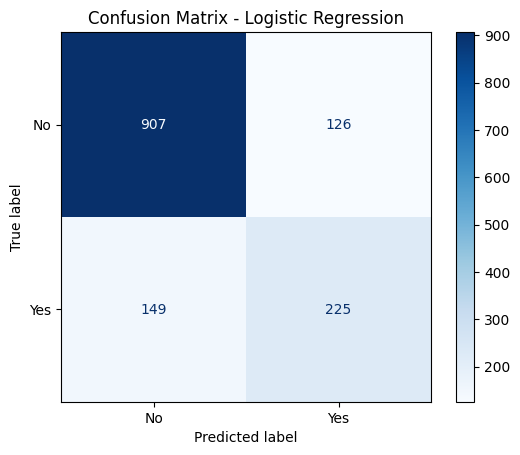

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()



The confusion matrix shows that the Logistic Regression model correctly classified most customers. It correctly identified **907 customers who stayed** and **225 customers who churned**. However, **149 churning customers were missed**, indicating that there is still room for improvement in detecting customers at risk of leaving.

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407





The Logistic Regression model performs very well in identifying customers who stay with the company. Its performance is lower for predicting customers who churn, which is expected due to the class imbalance. Overall, the model provides a strong baseline with good classification performance.

##Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

# Train the model

rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [54]:
# Make predictions

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

In [55]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf),4))
print("Precision:", round(precision_score(y_test, y_pred_rf),4))
print("Recall   :", round(recall_score(y_test, y_pred_rf),4))
print("F1-score :", round(f1_score(y_test, y_pred_rf),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf),4))

Accuracy : 0.7925
Precision: 0.634
Recall   : 0.5187
F1-score : 0.5706
ROC-AUC  : 0.8288



The Logistic Regression model outperformed the baseline Random Forest model across all evaluation metrics. It achieved higher Accuracy, Recall, F1-score, and ROC-AUC, making it the stronger baseline model for this customer churn prediction task.

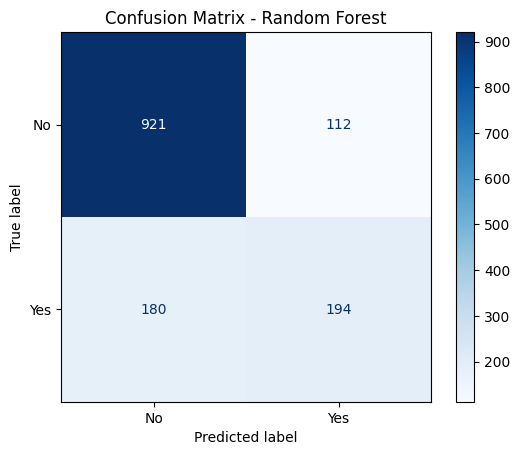

In [56]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No","Yes"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.show()



The Random Forest model correctly classified **921 customers who stayed** and **194 customers who churned**. However, it missed **180 customers who actually churned**, resulting in a lower recall compared to the Logistic Regression model.

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407





The Random Forest model achieved good overall performance, but it identified fewer customers who churned compared to the Logistic Regression model. This resulted in lower Recall and F1-score, indicating that the baseline Random Forest model is less effective at detecting customers at risk of leaving.

In [58]:
# Model comparison

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression": [0.8045, 0.6410, 0.6016, 0.6207, 0.8431],
    "Random Forest": [0.7925, 0.6340, 0.5187, 0.5706, 0.8288]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.8045,0.7925
1,Precision,0.6410,0.6340
2,Recall,0.6016,0.5187
3,F1-score,0.6207,0.5706
4,ROC-AUC,0.8431,0.8288



Logistic Regression performed better than Random Forest across all evaluation metrics. Therefore, Logistic Regression is currently the best baseline model.

In [59]:
#Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross-Validation ROC-AUC Scores:")
print(cv_scores)

print("\nMean ROC-AUC:", round(cv_scores.mean(),4))
print("Standard Deviation:", round(cv_scores.std(),4))

Cross-Validation ROC-AUC Scores:
[0.85982627 0.87656791 0.84641084 0.8517416  0.84885897]

Mean ROC-AUC: 0.8567
Standard Deviation: 0.0109



The 5-fold cross-validation results show that the Logistic Regression model performs consistently across different subsets of the data. The mean ROC-AUC score of **0.8567** and the low standard deviation (**0.0109**) indicate that the model is stable and generalizes well to unseen data.

In [60]:
#Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC:")
print(round(random_search.best_score_,4))

Best Parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}

Best ROC-AUC:
0.8619



RandomizedSearchCV identified a better set of hyperparameters for the Random Forest model. The tuned model achieved a cross-validation ROC-AUC score of **0.8619**, indicating an improvement over the baseline Random Forest model.

Accuracy : 0.7989
Precision: 0.6472
Recall   : 0.5348
F1-score : 0.5857
ROC-AUC  : 0.8434


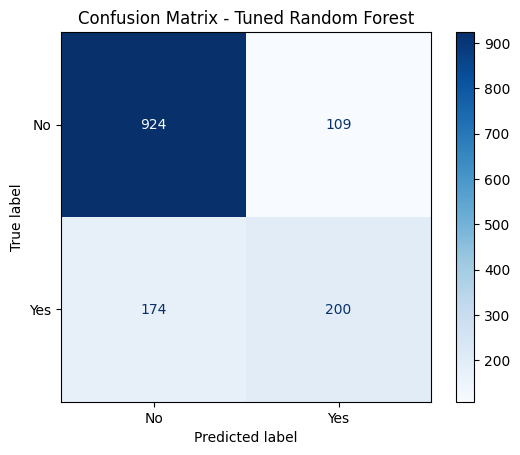

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.65      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [61]:
# Best tuned model

best_rf = random_search.best_estimator_

# Predictions

y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

print("Accuracy :", round(accuracy_score(y_test, y_pred_best),4))
print("Precision:", round(precision_score(y_test, y_pred_best),4))
print("Recall   :", round(recall_score(y_test, y_pred_best),4))
print("F1-score :", round(f1_score(y_test, y_pred_best),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_best),4))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances
importances = best_rf.named_steps["classifier"].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
feature_importance.head(15)

,Feature,Importance
0,num__Tenure Months,0.134901
37,cat__Contract_Month-to-month,0.107012
2,num__Total Charges,0.106149
1,num__Monthly Charges,0.070115
19,cat__Online Security_No,0.053490
28,cat__Tech Support_No,0.041833
17,cat__Internet Service_Fiber optic,0.041065
44,cat__Payment Method_Electronic check,0.040130
10,cat__Dependents_Yes,0.039703
39,cat__Contract_Two year,0.036890




The most important features are **Tenure Months**, **Contract Type**, **Total Charges**, and **Monthly Charges**. Customers with month-to-month contracts, fiber optic internet, electronic check payments, and no online security or technical support appear to have a higher risk of churn.

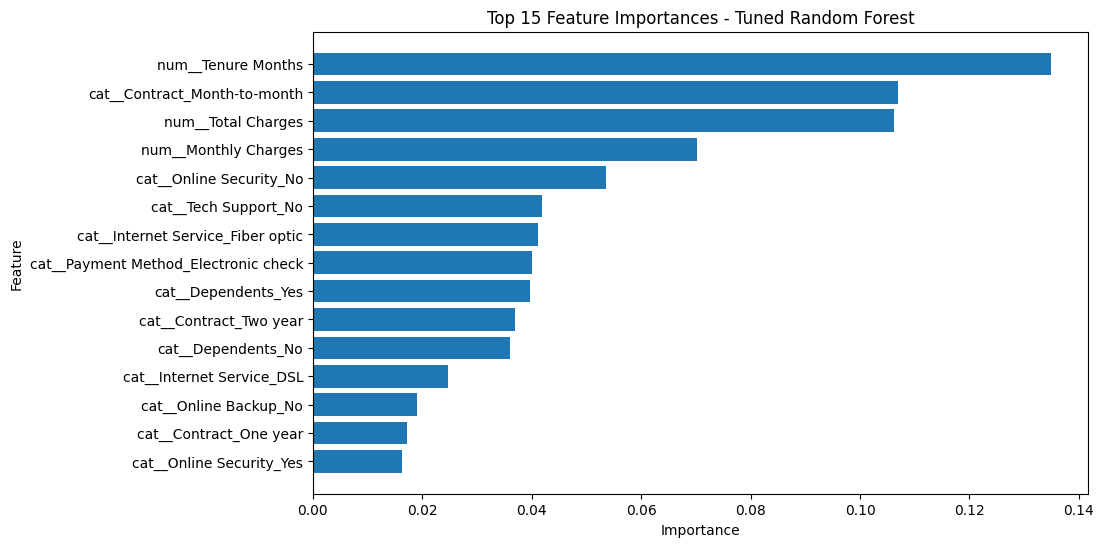

In [63]:
# Plot feature importance

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Tuned Random Forest")

plt.show()


The feature importance analysis shows that **Tenure Months** is the most influential factor in predicting customer churn. Other important features include **Month-to-month Contract**, **Total Charges**, **Monthly Charges**, **Online Security**, **Tech Support**, **Internet Service (Fiber Optic)**, and **Electronic Check** as the payment method.

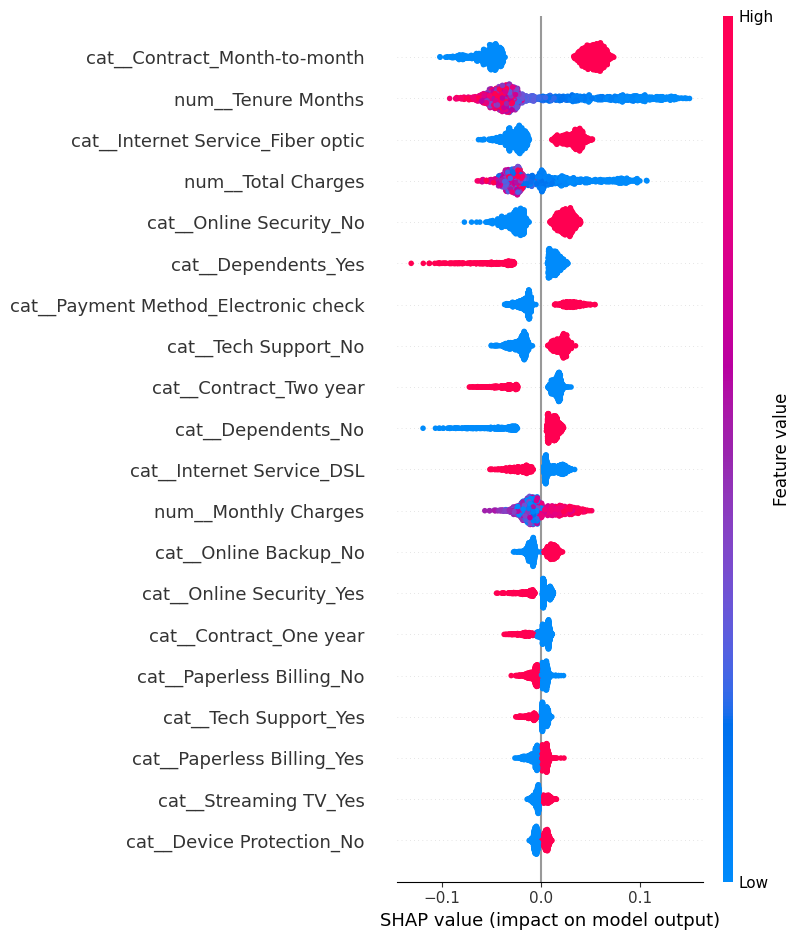

In [64]:
!pip install shap
import shap
# Transform the test data

X_test_transformed = best_rf.named_steps["preprocessor"].transform(X_test)

# Get feature names

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
# Create SHAP explainer

explainer = shap.TreeExplainer(best_rf.named_steps["classifier"])
# Compute SHAP values

shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names
)



The SHAP summary plot confirms that **Contract Type**, **Tenure Months**, **Total Charges**, and **Monthly Charges** are the most influential features in predicting customer churn. Customers with month-to-month contracts, shorter tenure, and without online security or technical support tend to have a higher probability of churning.

### Business Insights

- Customers with shorter tenure are more likely to churn.
- Customers with month-to-month contracts show a higher churn risk than customers with long-term contracts.
- Higher monthly charges are associated with an increased probability of churn.
- Customers without online security or technical support are more likely to leave the company.
- These findings can help the company identify high-risk customers and develop targeted retention strategies, such as personalized offers, discounts, or additional support services.

# Conclusion

This project developed and evaluated machine learning models to predict customer churn using customer demographic, service, and billing information.

Among the evaluated models, **Logistic Regression** achieved the highest Recall, making it the most effective model for identifying customers who are likely to churn. Hyperparameter tuning improved the performance of the Random Forest model, especially its ROC-AUC score, although Logistic Regression remained the preferred model for this dataset.

Feature Importance and SHAP analysis consistently identified **Tenure Months**, **Contract Type**, **Monthly Charges**, and **Total Charges** as the most influential factors affecting customer churn.

These insights can help companies identify customers at risk and implement targeted retention strategies, such as offering long-term contracts, personalized discounts, and additional support services.